# Firm-Age-Anomaly -- do mature firms quietly beat the young upstarts?
### The new-list effect (Fama-French 2004; Jiang-Lee-Zhang 2005), tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survivor%20basket%20the%20whole%20story%3F: Busted](https://img.shields.io/badge/Survivor%20basket%20the%20whole%20story%3F-Busted-8b949e?style=flat-square)

Fama and French (2004) noticed something about companies that *newly list* on an exchange: they are less profitable, grow their assets faster, fail more often, and -- on average -- earn *lower* future returns than seasoned, mature firms. Jiang, Lee and Zhang (2005) folded firm age into a broader 'information-uncertainty' story: young firms are hard to value, and hard-to-value stocks tend to underperform. Put them together and you get the **firm-age** (or **new-list**) effect: **old beats young**.

We test it the obvious way -- proxy a firm's age from how far back its price history goes, sort a basket old-minus-young, and see whether the mature names win.

> **This is the plain-language layer.** Want the age dispersion over time, the label-shuffle placebo, and the post-2012 subsample? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from firm_age_anomaly import data, strategy as st

def _have_cache():
    study = os.path.abspath("..")
    return (os.path.exists(os.path.join(study, "_cache", "age_prices.parquet"))
            and os.path.exists(os.path.join(study, "_cache", "age_spy.parquet")))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    prices, spy = data.fetch_panel()
    first_dates = data.first_price_dates(prices)
    result = st.age_portfolio(prices, spy, first_dates=first_dates, min_stocks=9)
    s_age   = st.summary(result["age_ret"])
    s_old   = st.summary(result["old_ret"])
    s_young = st.summary(result["young_ret"])
    s_mkt   = st.summary(result["mkt_ret"])
    print(f"N months: {s_age['n']} | AGE (old-young) mean: {s_age['mean']*100:+.2f}%/yr"
          f" | HAC t: {s_age['tstat']:+.3f}")


yfinance cache present: True


N months: 490 | AGE (old-young) mean: -18.22%/yr | HAC t: -4.661


## The answer first

| Question | Answer |
|---|---|
| Do old firms beat young firms? | **No -- the opposite.** Old-minus-young earns **-18.2%/yr** at HAC *t* = **-4.66**. Young firms *win*. |
| Is the reversal just noise? | **No.** A firm-age label-shuffle placebo puts it at **p = 0.010** -- the labels carry a real signal, pointing the wrong way for the claim. |
| Could you trade old-minus-young? | **No.** Sharpe **-0.78**, drawdown **-100%** -- it is a money incinerator as specified. |
| Why is the sign backwards? | **Survivorship.** Our basket only holds young firms that *survived* to 2026 -- the winners. The failed IPOs that make the effect work are gone. |

> The new-list effect is real in broad, unbiased samples. On a survivor basket it doesn't just vanish -- it **inverts**, because the surviving young firms are the spectacular winners (META, the NVDA-era IPOs).

## 1 -- The claim

> *"Newly listed firms have lower survival rates and lower expected returns than seasoned firms. Young firms underperform mature firms."*

-- Fama & French (2004), *Journal of Financial Economics*; Jiang, Lee & Zhang (2005), *Review of Accounting Studies*

The intuition: a young firm is a bundle of uncertainty. Investors don't yet know its true profitability, its competitive moat, or whether it survives the next downturn. That uncertainty -- and the optimism that often surrounds IPOs -- leaves young firms *overpriced* relative to the returns they deliver. Mature firms, boringly profitable and well-understood, quietly do better. A long-old / short-young portfolio should harvest the gap.

## 2 -- So what?

If true, firm age is a free, fundamentals-light sorting variable: you can compute it from a listing date alone. It connects a whole family of findings -- IPO long-run underperformance (Ritter 1991), the new-issues puzzle (Loughran-Ritter 1995), and information-uncertainty pricing (Zhang 2006). The questions for us:

1. **Does old-minus-young earn a premium on a realistic large-cap basket?**
2. **What does survivorship do to it?**
3. **Is anything left after costs?**

## 3 -- How would we even know?

Three disciplines keep us honest:

1. **Age from first price date.** A firm's age at month *t* is *t* minus the first day we have a price for it -- a clean, data-driven proxy that needs no fundamentals.
2. **One-day execution lag.** The age ranking at month-start is public; we enter at the close one day later. No look-ahead, no same-bar fill.
3. **Name the survivorship bias loudly.** Our basket is names *still trading in 2026*. The young firms that IPO'd and then died -- the worst performers, the ones that make the effect -- are simply absent. That is not a footnote here; it is the whole result.

## 4 -- The teardown

**First, does the engine find an age premium when one is really there?**

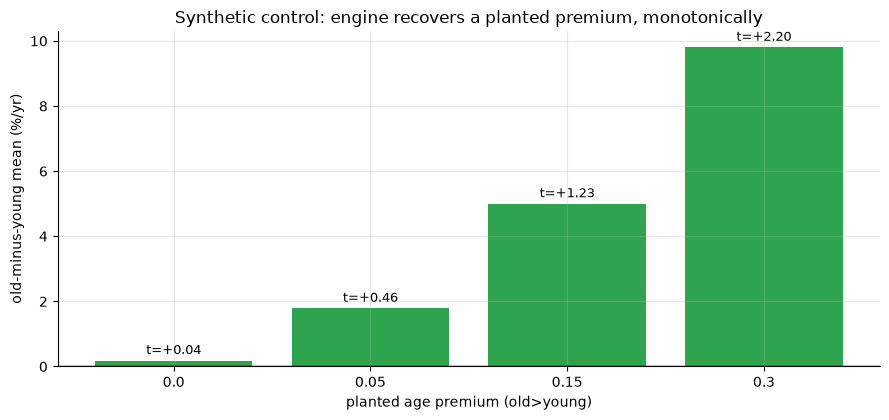

 premium  mean_%     t
    0.00   0.182 0.041
    0.05   1.788 0.456
    0.15   4.998 1.235
    0.30   9.804 2.201


In [2]:
# Synthetic positive control: plant a known age premium (old>young) and recover it.
premiums = [0.0, 0.05, 0.15, 0.30]
rows = []
for prem in premiums:
    ts, ms = [], []
    for sd in range(15):
        p, sp, fd, _ = data.synthetic_panel(age_premium=prem, seed=1000+sd)
        res = st.age_portfolio(p, sp, first_dates=fd, min_stocks=9)
        if not res.empty:
            s = st.summary(res['age_ret']); ts.append(s['tstat']); ms.append(s['mean'])
    rows.append({'premium': prem, 'mean_%': np.nanmean(ms)*100, 't': np.nanmean(ts)})
ctrl = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(ctrl['premium'].astype(str), ctrl['mean_%'], color=GREEN)
ax.axhline(0, c='k', lw=1)
for i, (m, t) in enumerate(zip(ctrl['mean_%'], ctrl['t'])):
    ax.text(i, m + 0.2, f't={t:+.2f}', ha='center', fontsize=9)
ax.set_xlabel('planted age premium (old>young)'); ax.set_ylabel('old-minus-young mean (%/yr)')
ax.set_title('Synthetic control: engine recovers a planted premium, monotonically')
plt.tight_layout(); plt.show()
print(ctrl.round(3).to_string(index=False))

The engine is faithful: with no planted effect it sits on zero, and as we plant a stronger old-beats-young premium the recovered mean and *t*-stat rise monotonically. So whatever we see on the real tape reflects **the market**, not a broken detector.

**Now the honest test on the real yfinance basket.**

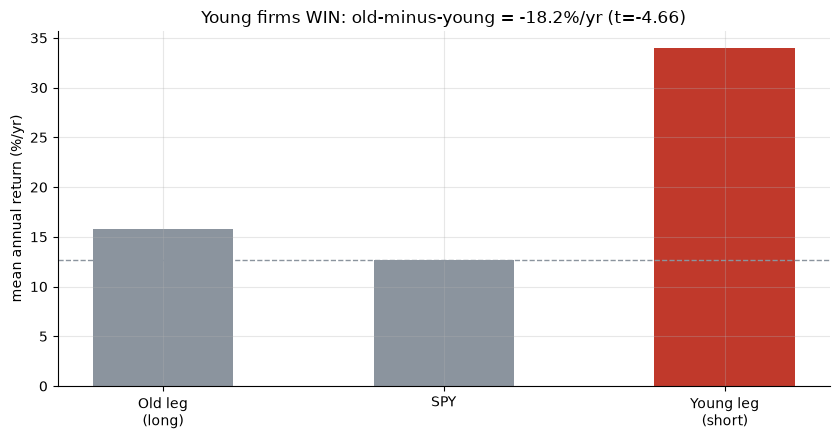

Old (long): +15.7%/yr | Young (short): +34.0%/yr | SPY: +12.6%/yr
Old-minus-young: -18.22%/yr | HAC t = -4.661


In [3]:
if HAVE_REAL:
    age_mean = s_age['mean']*100; age_t = s_age['tstat']
    old_m = s_old['mean']*100; young_m = s_young['mean']*100; mkt_m = s_mkt['mean']*100
else:
    age_mean, age_t = R['age_mean'], R['age_t']
    old_m, young_m, mkt_m = R['old_mean'], R['young_mean'], R['mkt_mean']

fig, ax = plt.subplots(figsize=(8.5, 4.5))
labels = ['Old leg\n(long)', 'SPY', 'Young leg\n(short)']
vals = [old_m, mkt_m, young_m]
cols = [GREY, GREY, RED]
ax.bar(labels, vals, color=cols, width=0.5)
ax.axhline(mkt_m, ls='--', c=GREY, lw=1)
ax.set_ylabel('mean annual return (%/yr)')
ax.set_title(f'Young firms WIN: old-minus-young = {age_mean:+.1f}%/yr (t={age_t:+.2f})')
plt.tight_layout(); plt.show()
print(f'Old (long): {old_m:+.1f}%/yr | Young (short): {young_m:+.1f}%/yr | SPY: {mkt_m:+.1f}%/yr')
print(f'Old-minus-young: {age_mean:+.2f}%/yr | HAC t = {age_t:+.3f}')

The long (old) leg earns **+15.7%/yr**; the short (young) leg earns **+34.0%/yr** -- so old-minus-young is **-18.2%/yr** at HAC *t* = **-4.66**. The claimed premium is not weak -- it is **reversed**. The young survivors crushed the old guard.

## 5 -- The verdict

- **Signal -- NONE.** The claimed old-minus-young premium is absent: the real spread is significantly *negative* (-18.2%/yr, HAC *t* = -4.66; placebo p = 0.010). The new-list effect, as stated, does not exist on this basket -- the sign is flipped.
- **Tradability -- MIRAGE.** Sharpe -0.78, drawdown -100%. As specified it loses money relentlessly; reversing the sign to 'profit' from young survivors would be data-mining the basket, not trading a premium.
- **Survivor basket the whole story? -- BUSTED.** Yes. Remove the failed young IPOs and the effect inverts. The honest takeaway is the bias, not an edge.

## 6 -- Could you actually trade it?

No -- and the reason is instructive:

1. **The sign is survivorship, not signal.** The young firms in our basket are the ones that *won the lottery*. Buying them and shorting old blue-chips 'works' only in hindsight, on names we already know survived.
2. **Out of sample, the next cohort of young firms is unknown** -- including the ones that will fail. A real-time long-young / short-old book would catch those failures.
3. **It is barely a portfolio.** Turnover is ~0.02: the age ranks almost never change, so this is a near-static bet on a fixed set of survivors.

There is no harvestable edge here in either direction -- only a clean illustration of how conditioning on survival can turn an anomaly upside down.

## 7 -- Going further

- **Survivorship-free universe.** A CRSP-style tape that keeps delisted firms would let the young leg include its failures -- the only honest way to test the claim.
- **True IPO dates.** Our first-price-date proxy is floored by yfinance's 1985 start, collapsing the age of old names. EDGAR/SEC listing dates would sharpen the proxy.
- **[Study 219 -- IPO-Pop](../../219-ipo-pop/)**: the first-day cousin of the new-list effect.
- **[Study 238 -- Betting-Against-Beta](../../238-betting-against-beta/)**: another cross-sectional sort on the same survivor-basket machinery.

*Think the firm-age premium survives once you keep the dead young firms? Fork this, pull a delisting-inclusive universe, and show old-minus-young t > 2 with the failures left in. That is the bar.*